# MediaPipe + TCN Classification Model
## ADSP 32023 - Advanced Computer Vision Using Deep Learning
## Spring 2026

In [ ]:
# ============================================================
# 0. Install packages
# ============================================================
!pip install -q torch torchvision torchaudio coremltools scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. Imports
# ============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

import coremltools as ct

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
# ============================================================
# 2. Paths + config
# ============================================================
drive.mount("/content/drive")
PROJECT_DIR = "/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 32023/Computer Vision Final Project/"

SAVE_DIR = os.path.join(PROJECT_DIR, "data", "preprocessed")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
GRAPH_DIR = os.path.join(PROJECT_DIR, "graphs")
RESULT_DIR = os.path.join(PROJECT_DIR, "data")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

EXPERIMENT_NAME = "torch_tcn_coreml"
OUTPUT_MODEL_DIR = os.path.join(MODEL_DIR, EXPERIMENT_NAME)
OUTPUT_GRAPH_DIR = os.path.join(GRAPH_DIR, EXPERIMENT_NAME)
OUTPUT_RESULT_DIR = os.path.join(RESULT_DIR, EXPERIMENT_NAME)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_GRAPH_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 80
N_SPLITS = 5

DROPOUT = 0.30
LR = 1e-3
WEIGHT_DECAY = 1e-5

Mounted at /content/drive


In [ ]:
# ============================================================
# 3. Load new extracted MediaPipe data
# ============================================================
X_verified = np.load(os.path.join(SAVE_DIR, "X_verified_mediapipe.npy"))
y_verified = np.load(os.path.join(SAVE_DIR, "y_verified.npy"))

X_test = np.load(os.path.join(SAVE_DIR, "X_test_mediapipe.npy"))
y_test = np.load(os.path.join(SAVE_DIR, "y_test.npy"))

kept_verified_df = pd.read_csv(
    os.path.join(SAVE_DIR, "kept_verified_mediapipe_dataset.csv")
)

with open(os.path.join(SAVE_DIR, "label_names.json"), "r") as f:
    label_names = json.load(f)

num_classes = len(label_names)
SEQUENCE_LENGTH = X_verified.shape[1]
FEATURE_SIZE = X_verified.shape[2]

print("X_verified:", X_verified.shape)
print("y_verified:", y_verified.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("SEQUENCE_LENGTH:", SEQUENCE_LENGTH)
print("FEATURE_SIZE:", FEATURE_SIZE)
print("num_classes:", num_classes)
print(label_names)

X_verified: (11897, 48, 300)
y_verified: (11897,)
X_test: (1293, 48, 300)
y_test: (1293,)
SEQUENCE_LENGTH: 48
FEATURE_SIZE: 300
num_classes: 21
['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'decline bench press', 'hammer curl', 'hip thrust', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'pull Up', 'push-up', 'romanian deadlift', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']


In [ ]:
# ============================================================
# 4. Scaling + augmentation helpers
# ============================================================
def scale_sequence_data(X_train, X_val):
    n_train, t, f = X_train.shape
    n_val = X_val.shape[0]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train.reshape(-1, f)
    ).reshape(n_train, t, f)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, f)
    ).reshape(n_val, t, f)

    return (
        X_train_scaled.astype(np.float32),
        X_val_scaled.astype(np.float32),
        scaler
    )


def scale_with_existing_scaler(X, scaler):
    n, t, f = X.shape

    X_scaled = scaler.transform(
        X.reshape(-1, f)
    ).reshape(n, t, f)

    return X_scaled.astype(np.float32)


def augment_sequence(
    seq,
    noise_std=0.015,
    scale_std=0.025,
    dropout_prob=0.06,
    time_shift_max=4,
    time_mask_prob=0.15,
    time_mask_max=5,
    feature_mask_prob=0.04
):
    aug = seq.copy()

    # Small feature noise
    aug += np.random.normal(0, noise_std, size=aug.shape)

    # Global scale jitter
    aug *= np.random.normal(1.0, scale_std)

    # Random time shift
    shift = np.random.randint(-time_shift_max, time_shift_max + 1)
    aug = np.roll(aug, shift=shift, axis=0)

    # Random frame dropout
    for i in range(1, len(aug)):
        if np.random.rand() < dropout_prob:
            aug[i] = aug[i - 1]

    # Time masking
    if np.random.rand() < time_mask_prob:
        mask_len = np.random.randint(1, time_mask_max + 1)
        start = np.random.randint(0, max(1, len(aug) - mask_len))
        replacement = aug[start - 1] if start > 0 else aug[start]
        aug[start:start + mask_len] = replacement

    # Feature masking
    feature_mask = np.random.rand(aug.shape[1]) < feature_mask_prob
    aug[:, feature_mask] = 0

    return aug.astype(np.float32)


def make_augmented_training_data(X_train, y_train, copies=2):
    X_list = [X_train]
    y_list = [y_train]

    for _ in range(copies):
        X_aug = np.array(
            [augment_sequence(seq) for seq in X_train],
            dtype=np.float32
        )
        X_list.append(X_aug)
        y_list.append(y_train)

    return np.concatenate(X_list), np.concatenate(y_list)

In [ ]:
# ============================================================
# 4. Scaling + augmentation helpers
# ============================================================
def scale_sequence_data(X_train, X_val):
    n_train, t, f = X_train.shape
    n_val = X_val.shape[0]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train.reshape(-1, f)
    ).reshape(n_train, t, f)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, f)
    ).reshape(n_val, t, f)

    return (
        X_train_scaled.astype(np.float32),
        X_val_scaled.astype(np.float32),
        scaler
    )


def scale_with_existing_scaler(X, scaler):
    n, t, f = X.shape

    X_scaled = scaler.transform(
        X.reshape(-1, f)
    ).reshape(n, t, f)

    return X_scaled.astype(np.float32)


def augment_sequence(
    seq,
    noise_std=0.015,
    scale_std=0.025,
    dropout_prob=0.06,
    time_shift_max=4,
    time_mask_prob=0.15,
    time_mask_max=5,
    feature_mask_prob=0.04
):
    aug = seq.copy()

    # Small feature noise
    aug += np.random.normal(0, noise_std, size=aug.shape)

    # Global scale jitter
    aug *= np.random.normal(1.0, scale_std)

    # Random time shift
    shift = np.random.randint(-time_shift_max, time_shift_max + 1)
    aug = np.roll(aug, shift=shift, axis=0)

    # Random frame dropout
    for i in range(1, len(aug)):
        if np.random.rand() < dropout_prob:
            aug[i] = aug[i - 1]

    # Time masking
    if np.random.rand() < time_mask_prob:
        mask_len = np.random.randint(1, time_mask_max + 1)
        start = np.random.randint(0, max(1, len(aug) - mask_len))
        replacement = aug[start - 1] if start > 0 else aug[start]
        aug[start:start + mask_len] = replacement

    # Feature masking
    feature_mask = np.random.rand(aug.shape[1]) < feature_mask_prob
    aug[:, feature_mask] = 0

    return aug.astype(np.float32)


def make_augmented_training_data(X_train, y_train, copies=2):
    X_list = [X_train]
    y_list = [y_train]

    for _ in range(copies):
        X_aug = np.array(
            [augment_sequence(seq) for seq in X_train],
            dtype=np.float32
        )
        X_list.append(X_aug)
        y_list.append(y_train)

    return np.concatenate(X_list), np.concatenate(y_list)

In [ ]:
# ============================================================
# 5. TCN model
# ============================================================
class TCNBlock(nn.Module):
    """
    Temporal Convolutional Network block.

    Uses:
    - Dilated Conv1D for longer temporal context
    - Residual connection
    - BatchNorm
    - ReLU
    - Dropout
    """

    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.3):
        super().__init__()

        padding = dilation * (kernel_size - 1) // 2

        self.conv1 = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + residual
        out = self.relu2(out)
        out = self.dropout2(out)

        return out


class WorkoutClassifierTCN(nn.Module):
    """
    TCN classifier for workout recognition.

    Input:
        (batch, time, features)

    Internal Conv1D format:
        (batch, features, time)

    Architecture:
    1. Input projection Conv1D
    2. Residual dilated TCN blocks
    3. Global average + max pooling
    4. Dense classifier head
    """

    def __init__(self, input_size, num_classes, dropout=0.3):
        super().__init__()

        self.input_projection = nn.Sequential(
            nn.Conv1d(input_size, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.tcn = nn.Sequential(
            TCNBlock(128, 128, kernel_size=3, dilation=1, dropout=dropout * 0.6),
            TCNBlock(128, 160, kernel_size=3, dilation=2, dropout=dropout * 0.7),
            TCNBlock(160, 192, kernel_size=3, dilation=4, dropout=dropout * 0.8),
            TCNBlock(192, 256, kernel_size=3, dilation=8, dropout=dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # (batch, time, features) -> (batch, features, time)
        x = x.transpose(1, 2)

        x = self.input_projection(x)
        x = self.tcn(x)

        avg_pool = torch.mean(x, dim=2)
        max_pool = torch.max(x, dim=2).values

        x = torch.cat([avg_pool, max_pool], dim=1)

        logits = self.classifier(x)

        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f"Total params: {total:,}")
    print(f"Trainable params: {trainable:,}")

In [ ]:
# ============================================================
# 6. Training helpers
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [ ]:
# ============================================================
# 7. Train with GroupKFold on verified data
# ============================================================
gkf = GroupKFold(n_splits=N_SPLITS)

groups = kept_verified_df["filepath"].values

fold_accuracies = []
fold_macro_f1 = []
fold_weighted_f1 = []

all_true = []
all_pred = []

best_val_acc = 0
best_model_state = None
best_scaler = None
best_history = None
best_fold = None

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_verified, y_verified, groups=groups),
    start=1
):
    print(f"\n================ Fold {fold} ================")

    X_train_raw = X_verified[train_idx]
    X_val_raw = X_verified[val_idx]

    y_train = y_verified[train_idx]
    y_val = y_verified[val_idx]

    X_train, X_val, scaler = scale_sequence_data(
        X_train_raw,
        X_val_raw
    )

    X_train_aug, y_train_aug = make_augmented_training_data(
        X_train,
        y_train,
        copies=2
    )

    train_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_train_aug),
            torch.LongTensor(y_train_aug)
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_val),
            torch.LongTensor(y_val)
        ),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = WorkoutClassifierTCN(
        input_size=FEATURE_SIZE,
        num_classes=num_classes,
        dropout=DROPOUT
    ).to(DEVICE)

    if fold == 1:
        count_parameters(model)

    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_aug),
        y=y_train_aug
    )

    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights_arr).to(DEVICE)
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=5,
        factor=0.5
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    fold_best_acc = 0
    fold_best_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        val_loss, val_acc, val_preds, val_labels = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            fold_best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d}/{EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(fold_best_state)
    model = model.to(DEVICE)

    val_loss, val_acc, val_preds, val_labels = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    macro = f1_score(
        val_labels,
        val_preds,
        average="macro"
    )

    weighted = f1_score(
        val_labels,
        val_preds,
        average="weighted"
    )

    fold_accuracies.append(val_acc)
    fold_macro_f1.append(macro)
    fold_weighted_f1.append(weighted)

    all_true.extend(val_labels)
    all_pred.extend(val_preds)

    print(f"\nFold {fold} Best Accuracy: {val_acc:.4f}")
    print(f"Fold {fold} Macro F1: {macro:.4f}")
    print(f"Fold {fold} Weighted F1: {weighted:.4f}")

    print(classification_report(
        val_labels,
        val_preds,
        target_names=label_names,
        zero_division=0
    ))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        best_scaler = scaler
        best_history = history
        best_fold = fold

print("\n================ Overall CV Results ================")
print("Mean Accuracy:", np.mean(fold_accuracies))
print("Mean Macro F1:", np.mean(fold_macro_f1))
print("Mean Weighted F1:", np.mean(fold_weighted_f1))
print("Best Fold:", best_fold)
print("Best Fold Accuracy:", best_val_acc)


================ Fold 1 ================
WorkoutClassifierTCN(
  (input_projection): Sequential(
    (0): Conv1d(300, 128, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (dropout1): Dropout(p=0.18, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
      (dropout2): Dropout(p=0.18, inplace=False)
      (shortcut): Identity()
    )
    (1): TCNBlock(
      (conv1): Conv1d(128, 160, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn1): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=Tru

,fold,accuracy,macro_f1,weighted_f1
0,1,0.874370,0.871113,0.873021
1,2,0.892437,0.881854,0.893068
2,3,0.880622,0.875905,0.880951
3,4,0.865910,0.868242,0.865559
4,5,0.884826,0.882464,0.885217


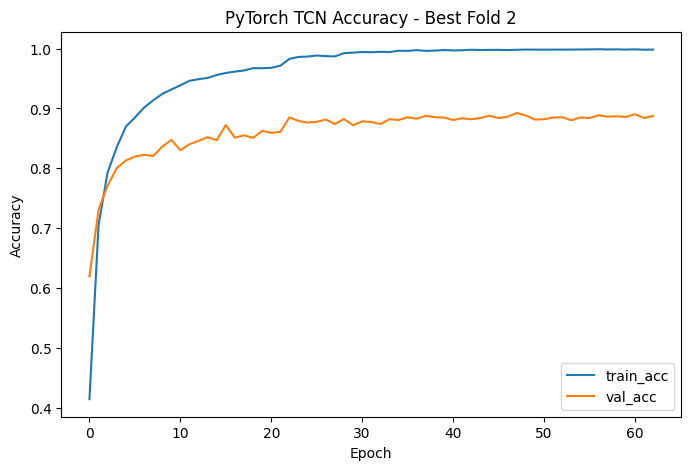

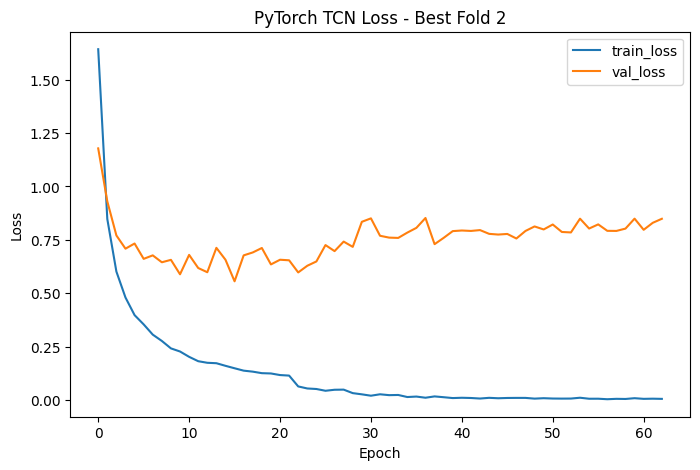

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_cv_results.csv
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_accuracy.png
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_loss.png


In [ ]:
# ============================================================
# 8. Save CV results + graphs
# ============================================================
results_df = pd.DataFrame({
    "fold": list(range(1, len(fold_accuracies) + 1)),
    "accuracy": fold_accuracies,
    "macro_f1": fold_macro_f1,
    "weighted_f1": fold_weighted_f1
})

CV_RESULTS_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_tcn_cv_results.csv"
)

results_df.to_csv(
    CV_RESULTS_PATH,
    index=False
)

display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_acc"], label="train_acc")
plt.plot(best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"PyTorch TCN Accuracy - Best Fold {best_fold}")
plt.legend()

ACC_PLOT_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_tcn_accuracy.png"
)

plt.savefig(
    ACC_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(best_history["train_loss"], label="train_loss")
plt.plot(best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"PyTorch TCN Loss - Best Fold {best_fold}")
plt.legend()

LOSS_PLOT_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_tcn_loss.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", CV_RESULTS_PATH)
print("Saved:", ACC_PLOT_PATH)
print("Saved:", LOSS_PLOT_PATH)

,precision,recall,f1-score,support
barbell biceps curl,0.759234,0.771905,0.765517,719.000000
bench press,0.708087,0.697087,0.702544,515.000000
chest fly machine,0.911450,0.949126,0.929907,629.000000
deadlift,0.839695,0.825516,0.832545,533.000000
decline bench press,0.850051,0.905070,0.876698,927.000000
hammer curl,0.820282,0.854278,0.836935,748.000000
hip thrust,0.937864,0.911321,0.924402,530.000000
incline bench press,0.850299,0.900634,0.874743,473.000000
lat pulldown,0.859838,0.852941,0.856376,374.000000
lateral raise,0.910345,0.902050,0.906178,439.000000


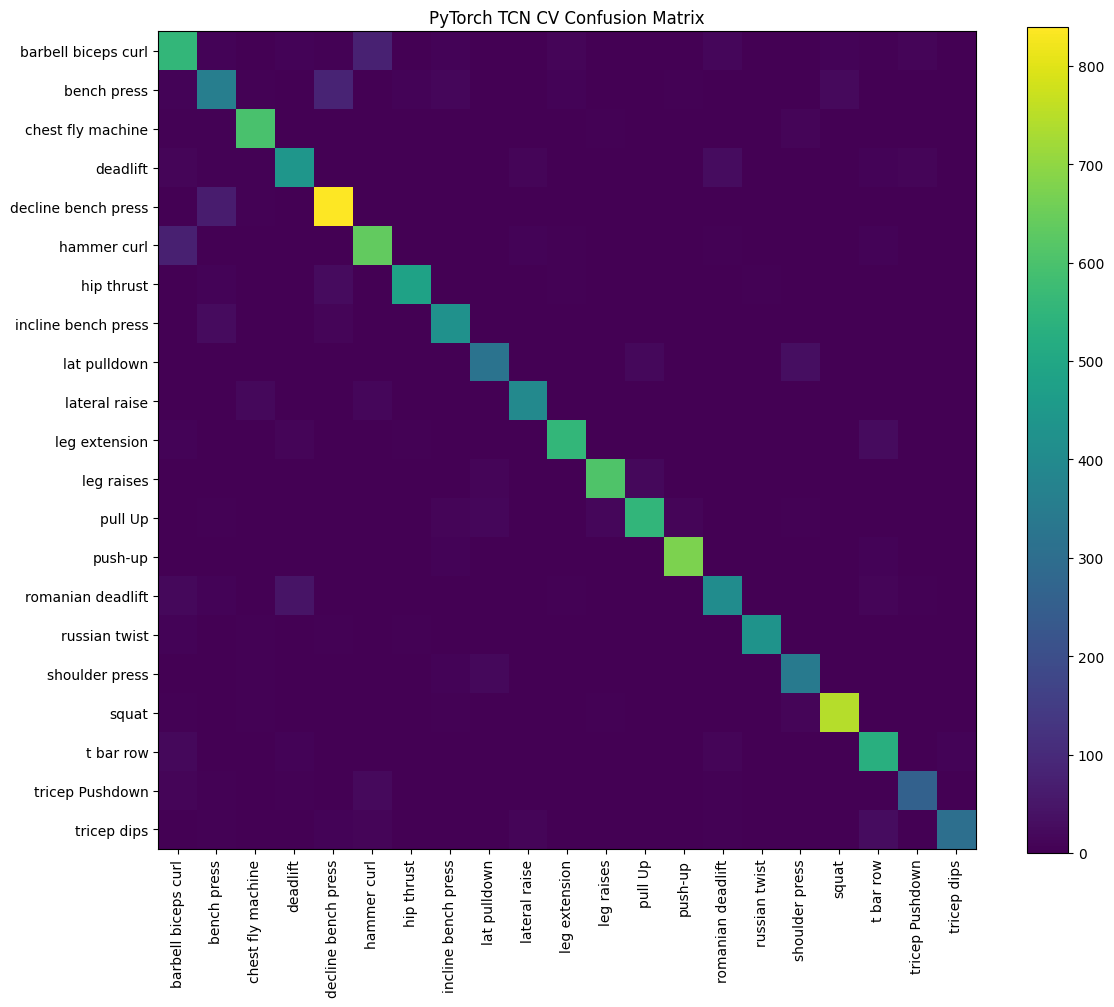

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_cv_classification_report.csv
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_cv_confusion_matrix.png


In [ ]:
# ============================================================
# 9. CV classification report + confusion matrix
# ============================================================
overall_report = classification_report(
    all_true,
    all_pred,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(overall_report).transpose()

REPORT_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_tcn_cv_classification_report.csv"
)

report_df.to_csv(REPORT_PATH)

display(report_df)

cm = confusion_matrix(
    all_true,
    all_pred
)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("PyTorch TCN CV Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=90
)

plt.yticks(
    range(len(label_names)),
    label_names
)

plt.tight_layout()

CM_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_tcn_cv_confusion_matrix.png"
)

plt.savefig(
    CM_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

np.save(
    os.path.join(OUTPUT_RESULT_DIR, "torch_tcn_cv_confusion_matrix.npy"),
    cm
)

print("Saved:", REPORT_PATH)
print("Saved:", CM_PATH)

In [ ]:
# ============================================================
# 10. Retrain final TCN on ALL verified data
# ============================================================
final_scaler = StandardScaler()

n, t, f = X_verified.shape

X_verified_scaled = final_scaler.fit_transform(
    X_verified.reshape(-1, f)
).reshape(n, t, f).astype(np.float32)

X_verified_aug, y_verified_aug = make_augmented_training_data(
    X_verified_scaled,
    y_verified,
    copies=2
)

train_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_verified_aug),
        torch.LongTensor(y_verified_aug)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

final_model = WorkoutClassifierTCN(
    input_size=FEATURE_SIZE,
    num_classes=num_classes,
    dropout=DROPOUT
).to(DEVICE)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_verified_aug),
    y=y_verified_aug
)

criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(class_weights_arr).to(DEVICE)
)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

FINAL_EPOCHS = 40

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        final_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Final Epoch {epoch:03d}/{FINAL_EPOCHS} | "
            f"Loss: {train_loss:.4f} | "
            f"Acc: {train_acc:.4f}"
        )

final_model.eval()

Final Epoch 001/40 | Loss: 1.5618 | Acc: 0.4530
Final Epoch 005/40 | Loss: 0.3701 | Acc: 0.8785
Final Epoch 010/40 | Loss: 0.2094 | Acc: 0.9366
Final Epoch 015/40 | Loss: 0.1557 | Acc: 0.9545
Final Epoch 020/40 | Loss: 0.1331 | Acc: 0.9648
Final Epoch 025/40 | Loss: 0.1162 | Acc: 0.9709
Final Epoch 030/40 | Loss: 0.0948 | Acc: 0.9748
Final Epoch 035/40 | Loss: 0.0901 | Acc: 0.9790
Final Epoch 040/40 | Loss: 0.0865 | Acc: 0.9783


WorkoutClassifierTCN(
  (input_projection): Sequential(
    (0): Conv1d(300, 128, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (dropout1): Dropout(p=0.18, inplace=False)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
      (dropout2): Dropout(p=0.18, inplace=False)
      (shortcut): Identity()
    )
    (1): TCNBlock(
      (conv1): Conv1d(128, 160, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn1): BatchNorm1d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1)

In [ ]:
# ============================================================
# 11. Evaluate final model on official test split
# ============================================================
X_test_scaled = scale_with_existing_scaler(
    X_test,
    final_scaler
)

test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_test_scaled),
        torch.LongTensor(y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loss, test_acc, test_preds, test_labels = evaluate(
    final_model,
    test_loader,
    criterion,
    DEVICE
)

test_macro = f1_score(
    test_labels,
    test_preds,
    average="macro"
)

test_weighted = f1_score(
    test_labels,
    test_preds,
    average="weighted"
)

print("Official Test Accuracy:", test_acc)
print("Official Test Macro F1:", test_macro)
print("Official Test Weighted F1:", test_weighted)

print(classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0
))

Official Test Accuracy: 0.5870069605568445
Official Test Macro F1: 0.5585083781250638
Official Test Weighted F1: 0.5763533953168734
                     precision    recall  f1-score   support

barbell biceps curl       0.28      0.71      0.40        49
        bench press       0.26      0.92      0.41        36
  chest fly machine       0.61      0.76      0.68        89
           deadlift       0.74      0.77      0.75       156
decline bench press       0.44      0.49      0.47        83
        hammer curl       0.00      0.00      0.00        49
         hip thrust       0.81      0.54      0.65        70
incline bench press       0.05      0.01      0.02        77
       lat pulldown       0.45      0.29      0.36        34
      lateral raise       0.86      0.46      0.60        26
      leg extension       0.62      0.97      0.76        36
         leg raises       1.00      0.64      0.78        70
            pull Up       0.74      0.69      0.72        62
            p

,precision,recall,f1-score,support
barbell biceps curl,0.282258,0.714286,0.404624,49.000000
bench press,0.264000,0.916667,0.409938,36.000000
chest fly machine,0.607143,0.764045,0.676617,89.000000
deadlift,0.736196,0.769231,0.752351,156.000000
decline bench press,0.440860,0.493976,0.465909,83.000000
hammer curl,0.000000,0.000000,0.000000,49.000000
hip thrust,0.808511,0.542857,0.649573,70.000000
incline bench press,0.052632,0.012987,0.020833,77.000000
lat pulldown,0.454545,0.294118,0.357143,34.000000
lateral raise,0.857143,0.461538,0.600000,26.000000


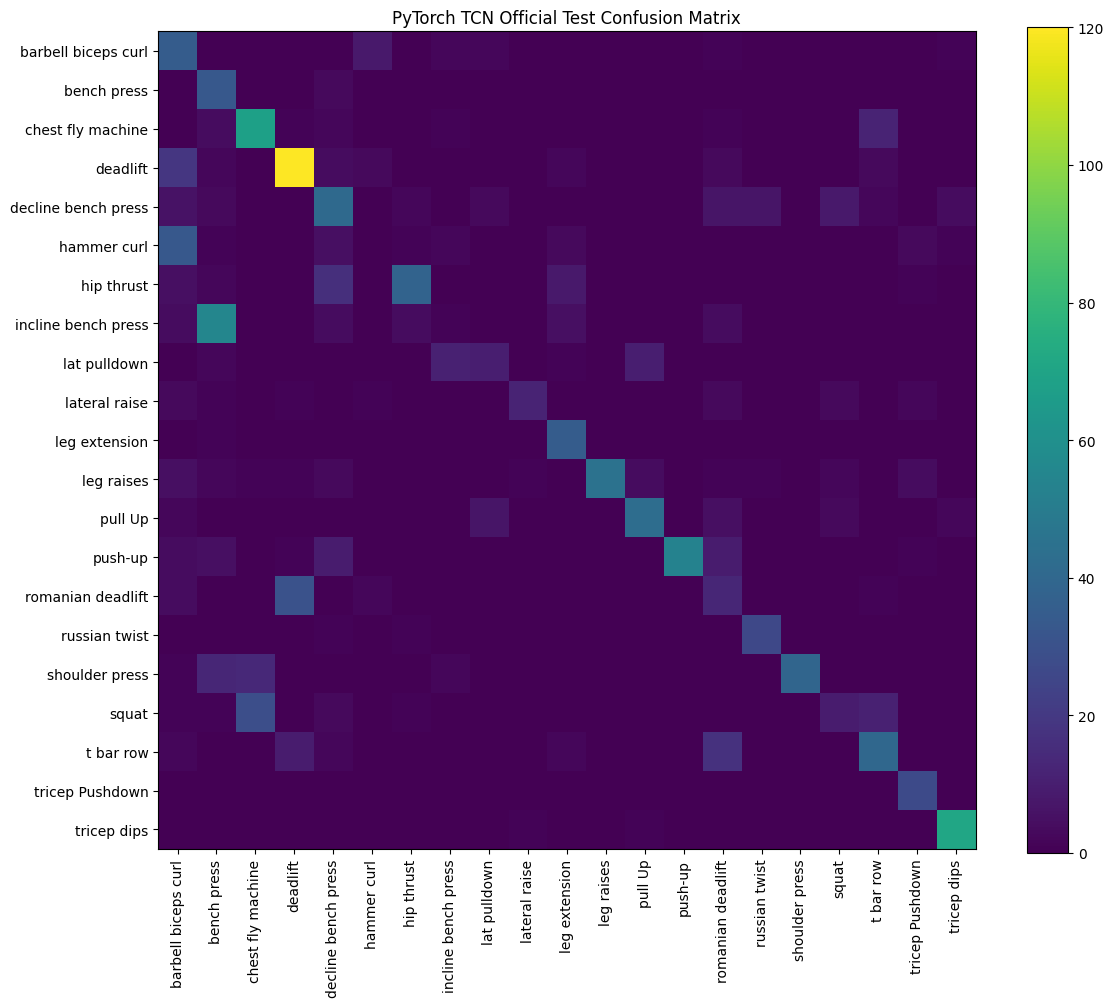

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_official_test_report.csv
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/torch_tcn_official_test_confusion_matrix.png


In [ ]:
# ============================================================
# 12. Save official test report + confusion matrix
# ============================================================
test_report = classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    zero_division=0,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report).transpose()

TEST_REPORT_PATH = os.path.join(
    OUTPUT_RESULT_DIR,
    "torch_tcn_official_test_report.csv"
)

test_report_df.to_csv(TEST_REPORT_PATH)

display(test_report_df)

test_cm = confusion_matrix(
    test_labels,
    test_preds
)

plt.figure(figsize=(12, 10))
plt.imshow(test_cm)
plt.title("PyTorch TCN Official Test Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=90
)

plt.yticks(
    range(len(label_names)),
    label_names
)

plt.tight_layout()

TEST_CM_PATH = os.path.join(
    OUTPUT_GRAPH_DIR,
    "torch_tcn_official_test_confusion_matrix.png"
)

plt.savefig(
    TEST_CM_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

np.save(
    os.path.join(OUTPUT_RESULT_DIR, "torch_tcn_official_test_confusion_matrix.npy"),
    test_cm
)

print("Saved:", TEST_REPORT_PATH)
print("Saved:", TEST_CM_PATH)

In [ ]:
# ============================================================
# 13. Save checkpoint + scaler + labels
# ============================================================
CHECKPOINT_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "best_workout_tcn_model.pth"
)

checkpoint = {
    "model_state_dict": final_model.cpu().state_dict(),

    "hyperparams": {
        "input_size": FEATURE_SIZE,
        "num_classes": num_classes,
        "dropout": DROPOUT,
        "sequence_length": SEQUENCE_LENGTH
    },

    "label_names": label_names,
    "test_accuracy": test_acc,
    "test_macro_f1": test_macro,
    "test_weighted_f1": test_weighted
}

torch.save(
    checkpoint,
    CHECKPOINT_PATH
)

SCALER_JSON_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "mediapipe_scaler.json"
)

with open(SCALER_JSON_PATH, "w") as f:
    json.dump({
        "mean": final_scaler.mean_.tolist(),
        "scale": final_scaler.scale_.tolist()
    }, f)

LABEL_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "label_names.json"
)

with open(LABEL_PATH, "w") as f:
    json.dump(label_names, f)

print("Saved checkpoint:", CHECKPOINT_PATH)
print("Saved scaler:", SCALER_JSON_PATH)
print("Saved labels:", LABEL_PATH)

Saved checkpoint: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/best_workout_tcn_model_new_dataset.pth
Saved scaler: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/mediapipe_scaler.json
Saved labels: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/label_names.json


In [ ]:
# ============================================================
# 14. Convert final TCN model to CoreML
# ============================================================
export_model = WorkoutClassifierTCN(
    input_size=FEATURE_SIZE,
    num_classes=num_classes,
    dropout=DROPOUT
)

export_model.load_state_dict(
    checkpoint["model_state_dict"]
)

export_model.eval()

example_input = torch.rand(
    1,
    SEQUENCE_LENGTH,
    FEATURE_SIZE
)

with torch.no_grad():
    example_output = export_model(example_input)

print("Example input:", example_input.shape)
print("Example output:", example_output.shape)

traced_model = torch.jit.trace(
    export_model,
    example_input
)

coreml_model = ct.convert(
    traced_model,
    inputs=[
        ct.TensorType(
            name="input",
            shape=example_input.shape
        )
    ],
    outputs=[
        ct.TensorType(
            name="logits"
        )
    ],
    convert_to="mlprogram",
    minimum_deployment_target=ct.target.iOS15
)

COREML_PATH = os.path.join(
    OUTPUT_MODEL_DIR,
    "WorkoutClassifierTCN.mlpackage"
)

coreml_model.save(
    COREML_PATH
)

print("Saved CoreML model:", COREML_PATH)

Example input: torch.Size([1, 48, 300])
Example output: torch.Size([1, 21])


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 392.46 passes/s]


Saved CoreML model: /content/drive/MyDrive/UChicago/Masters/Spring/Computer Vision/Computer Vision Final Project/mediapipe_pose_exercise_new_dataset/torch_tcn_coreml/WorkoutClassifierTCN.mlpackage
